In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import argparse
import os
from pathlib import Path
import json
import re
import numpy as np
import importlib
from typing import Callable, Any
OUTPUT_DIR = "results-bcra/paper_graphics"


In [2]:

ALGORITHMS = {}
ALGORITHMS['cryptography'] = {
    'ecdsa': {
        1: 'P-256',
        3: 'P-384',
        5: 'P-521'
    },
}

ALGORITHMS['liboqs'] =  {
    'mldsa': {
        1: 'ML-DSA-44',
        2: 'ML-DSA-44',
        3: 'ML-DSA-65',
        5: 'ML-DSA-87'
    },
    'dilithium': {
        1: 'Dilithium2',
        2: 'Dilithium2',
        3: 'Dilithium3',
        5: 'Dilithium5'
    },
    'sphincs-sha-s': {
        1: 'SPHINCS+-SHA2-128s-simple',
        3: 'SPHINCS+-SHA2-192s-simple',
        5: 'SPHINCS+-SHA2-256s-simple'
    },
    'sphincs-sha-f': {
        1: 'SPHINCS+-SHA2-128f-simple',
        3: 'SPHINCS+-SHA2-192f-simple',
        5: 'SPHINCS+-SHA2-256f-simple'
    },
    'sphincs-shake-s': {
        1: 'SPHINCS+-SHAKE-128s-simple',
        3: 'SPHINCS+-SHAKE-192s-simple',
        5: 'SPHINCS+-SHAKE-256s-simple'
    },
    'sphincs-shake-f': {
        1: 'SPHINCS+-SHAKE-128f-simple',
        3: 'SPHINCS+-SHAKE-192f-simple',
        5: 'SPHINCS+-SHAKE-256f-simple'
    },
    'falcon': {
        1: 'Falcon-512',
        5: 'Falcon-1024'
    },
    'falcon-padded': {
        1: 'Falcon-padded-512',
        5: 'Falcon-padded-1024'
    },
    'mayo': {
        1: 'MAYO-2',
        3: 'MAYO-3',
        5: 'MAYO-5'
    },
    'cross-rsdp-small': {
        1: 'cross-rsdp-128-small',
        3: 'cross-rsdp-192-small',
        5: 'cross-rsdp-256-small'
    },
    'cross-rsdpg-small': {
        1: 'cross-rsdpg-128-small',
        3: 'cross-rsdpg-192-small',
        5: 'cross-rsdpg-256-small'
    },
    'cross-rsdp-balanced': {
        1: 'cross-rsdp-128-balanced',
        3: 'cross-rsdp-192-balanced',
        5: 'cross-rsdp-256-balanced'
    },
    'cross-rsdpg-balanced': {
        1: 'cross-rsdpg-128-balanced',
        3: 'cross-rsdpg-192-balanced',
        5: 'cross-rsdpg-256-balanced'
    },
    'cross-rsdp-fast': {
        1: 'cross-rsdp-128-fast',
        3: 'cross-rsdp-192-fast',
        5: 'cross-rsdp-256-fast'
    },
    'cross-rsdpg-fast': {
        1: 'cross-rsdpg-128-fast',
        3: 'cross-rsdpg-192-fast',
        5: 'cross-rsdpg-256-fast'
    }
}


In [3]:
def ensure_output_dir(output_dir):
    """
    Checks if OUTPUT_DIR exists, and creates it if not.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")
    else:
        print(f"Directory already exists: {output_dir}")

ensure_output_dir(OUTPUT_DIR)

Directory already exists: results-bcra/paper_graphics


In [ ]:
def find_csv_recursive(root_dir, filename):
    """
    Recursively search for a file named `filename` in `root_dir`.
    Returns the full path if found, else None.
    """
    for dirpath, _, files in os.walk(root_dir):
        if filename in files:
            return os.path.join(dirpath, filename)
    return None

def load_results(input_dir,  index_col="variant"):
    """
    Loads CSV data from each subdirectory in input_dir.
    Returns a dictionary:
    {
        'subdir_name': {
            'time-evaluation-tmean-std': pd.DataFrame,
            'blocksim-mean-std': pd.DataFrame
        },
        ...
    }
    """
    results = {}
    colunas_em_bytes = [
        'mean_artifacts_size', 
        'std_artifacts_size',
    ]
    for subdir in os.listdir(input_dir):
        subdir_path = os.path.join(input_dir, subdir)
        if os.path.isdir(subdir_path):
            data = {}
            for key in ['blocksim-model-2-mean-std', 'blocksim-model-1-mean-std']:
                csv_path = find_csv_recursive(subdir_path, f"{key}.csv")
                if csv_path:
                    df = pd.read_csv(csv_path, index_col=index_col)
                    
                    colunas_presentes = [col for col in colunas_em_bytes if col in df.columns]
                    df[colunas_presentes] = df[colunas_presentes] / 1024
                    
                    data[key] = df
                else:
                    data[key] = None  # or pd.DataFrame() if preferred
            results[subdir] = data
    return results

results = load_results("results-bcra")
print(results)  # Print the keys to verify loading

{'scenario2': {'blocksim-model-2-mean-std':                             mean_verify  std_verify  mean_artifacts_size  \
variant                                                                    
Dilithium2                     3.481740    0.071819           476.267680   
Dilithium3                     5.462138    0.111786           668.655530   
Dilithium5                     8.454173    0.176738           916.547236   
Falcon-1024                   11.652516    0.237196           390.626557   
Falcon-512                     6.232290    0.126522           197.948040   
Falcon-padded-1024            11.591886    0.234151           391.616916   
Falcon-padded-512              6.212505    0.129324           199.263117   
MAYO-2                         3.181942    0.066972           722.629792   
MAYO-3                        11.073338    0.223339           412.598364   
MAYO-5                        22.092015    0.457925           745.033729   
ML-DSA-44                      3.474948    0

In [5]:
def get_variants_by_level(df, variant_dict):
    csv_variants = set(df.index.to_list())
    print("CSV Variants:", csv_variants)
    variants_by_level = {}

    for algorithm, levels in variant_dict.items():
        for level, variant in levels.items():
            if variant in csv_variants:
                variants_by_level.setdefault(level, []).append({
                    "algorithm": algorithm,
                    "variant": variant
                })
             
    return dict(sorted(variants_by_level.items()))

def filter_algorithms(algorithms: dict, selected_algorithms: list = None, selected_levels: list = None) -> dict:
    selected_algorithms = selected_algorithms or []
    selected_levels = selected_levels or []

    filtered = {}

    for module, algos in algorithms.items():
        for algorithm, variants in algos.items():
            if selected_algorithms and algorithm not in selected_algorithms:
                continue

            selected_variants = {
                level: name for level, name in variants.items()
                if not selected_levels or level in selected_levels
            }

            if selected_variants:
                filtered.setdefault(module, {})[algorithm] = selected_variants

    return filtered


In [25]:
def algorithm_to_label(algorithm):
    mapping = {
        'ecdsa': 'ECDSA',
        'mldsa': 'ML-DSA',
        'dilithium': 'Dilithium',
        'sphincs-sha-s': 'SPHINCS+-SHA-s',
        'sphincs-sha-f': 'SPHINCS+-SHA-f',
        'sphincs-shake-s': 'SPHINCS+-SHAKE-s',
        'sphincs-shake-f': 'SPHINCS+-SHAKE-f',
        'falcon': 'Falcon',
        'falcon-padded': 'Falcon-padded',
        'mayo': 'MAYO',
        'cross-rsdp-small': 'CROSS-RSDP-small',
        'cross-rsdpg-small': 'CROSS-RSDPG-small',
        'cross-rsdp-balanced': 'CROSS-RSDP-balanced',
        'cross-rsdpg-balanced': 'CROSS-RSDPG-balanced',
        'cross-rsdp-fast': 'CROSS-RSDP-fast',
        'cross-rsdpg-fast': 'CROSS-RSDPG-fast'
    }
    return mapping.get(algorithm, algorithm)

In [ ]:
def plot_horizontal_multiple_inverted(
    dfs,                # lista de DataFrames
    columns,
    graphics_directory,
    values_offset,
    error_offset,
    levels=None,        # lista de níveis (opcional)
    xscale="linear",
    xlabel=None,
    xlim=None,
    xticks=None,
    yticklabels="operation",  # Agora são as operações no eixo Y
    figsize=None,
    width=0.7,
    titles=None,        # lista de títulos (opcional)
    ylabel=None,
    show_graph=False,
    show_values=True,
    show_errors=True,
    show_legend=True,
    save_formats=("pdf", "png"),
    file_name="multiples",
    pallet_start=0,
    legend_location="center left"
):
    """
    Plota múltiplos gráficos horizontais em uma única figura, um para cada DataFrame da lista.
    Agora cada barra representa uma operação e os grupos representam os algoritmos.
    """
    n_plots = len(dfs)
    fig, axes = plt.subplots(1, 1, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    fontsize = 18 
    
    for idx, df in enumerate(dfs):
        # Get list of unique algorithms
        algorithms = df['algorithm'].unique()
        n_algorithms = len(algorithms)
        n_operations = len(columns) 
        
        width_bar = width / n_algorithms
        y = np.arange(n_operations)
        ax = axes[idx]
        palette = sns.color_palette("muted", n_colors=len(algorithms) + pallet_start)
        
        max_x_value = 0
        
        for algo_idx, algorithm in enumerate(algorithms):
            color = palette[algo_idx + pallet_start]
            
            # Finding the data for this algorithm
            algo_data = df[df['algorithm'] == algorithm]
            if len(algo_data) == 0:
                continue
                
            # Collect values ​​for all operations of this algorithm.
            values = []
            errors = []
            operation_labels = []
            print(columns)
             
            for i, (val_col, err_col, label) in enumerate(columns):
                if len(algo_data) > 0:
                    val = algo_data[val_col].iloc[0]
                    err = algo_data[err_col].iloc[0] if err_col in algo_data else 0
                    values.append(val)
                    errors.append(err)
                    operation_labels.append(label)
                    
                    if val + err > max_x_value:
                        max_x_value = val + err

            bars = ax.barh(
                y + ((n_algorithms - 1 - algo_idx) - (n_algorithms - 1) / 2) * width_bar,
                values,
                height=width_bar,
                xerr=errors if show_errors else None,
                label= algorithm_to_label(algorithm),  # Label is the name of the algorithm.
                color=color,
                error_kw={"capsize": 3, "ecolor": "red", "elinewidth": 2}
            )

            if show_values:
                for bar, value, err in zip(bars, values, errors):
                    if value == 0 or np.isnan(value): 
                        ax.text(
                            values_offset,
                            bar.get_y() + bar.get_height() / 2,
                            "N/A",
                            va="center",
                            ha="left",
                            fontsize=fontsize-4,
                            color="black",
                            clip_on=False
                        )
                    else:
                        x_pos = value + (err if show_errors else 0) + values_offset
                        ax.text(
                            x_pos,
                            bar.get_y() + bar.get_height() / 2,
                            f"{value:.2f}",
                            va="center",
                            ha="left",
                            fontsize=fontsize-5,
                            color="black",
                            clip_on=False
                        )

        # Configure Y-axis labels with operation names.
        ax.set_yticks(y)
        operation_names = [col[2] for col in columns]
        ax.set_yticklabels(operation_names, rotation=90, va="center", fontsize=fontsize)

        if ylabel:
            ax.set_ylabel(ylabel, fontsize=fontsize)
        if xlabel:
            ax.set_xlabel(xlabel, fontsize=fontsize)
        if titles and idx < len(titles):
            ax.set_title(titles[idx], fontsize=fontsize+50)

        ax.set_xscale(xscale)
        if xscale == "log" and xticks is not None:
            ax.set_xticks(xticks)
        if xscale == "linear":
            if xlim is not None and xlim[1] is not None:
                ax.set_xlim(*xlim)
            else:
                # If it doesn't receive a xlim, add 15% extra space on the right to fit the text.
                ax.set_xlim(0, max_x_value * 1.15)
        
        if len(y) > 0:
            ax.set_ylim(y[0] - 0.5, y[-1] + 0.5)
        
        ax.tick_params(axis="y", labelsize=fontsize)
        ax.tick_params(axis="x", labelsize=fontsize)
        
        if show_legend:
            ax.legend(
                loc="upper center",
                bbox_to_anchor=(0.5, -0.25), 
                ncol=4,
                fontsize=fontsize-2,
                frameon=True,
                borderpad=0.8,
                handletextpad=0.5,
                columnspacing=1.2
            )
        ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

    plt.tight_layout()
    
    for ext in save_formats:
        file = f"{graphics_directory}/{file_name}.{ext}"
        plt.savefig(file, format=ext, bbox_inches='tight')
        print(f"Saved: {file}")

    if show_graph:
        plt.show()
    plt.close()

All algorithms loaded: ['cryptography', 'liboqs']
Filtered algorithms: {'cryptography': {'ecdsa': {1: 'P-256', 3: 'P-384', 5: 'P-521'}}, 'liboqs': {'falcon': {1: 'Falcon-512', 5: 'Falcon-1024'}, 'falcon-padded': {1: 'Falcon-padded-512', 5: 'Falcon-padded-1024'}, 'mayo': {1: 'MAYO-2', 3: 'MAYO-3', 5: 'MAYO-5'}}}
Combined mechanisms: {'ecdsa': {1: 'P-256', 3: 'P-384', 5: 'P-521'}, 'falcon': {1: 'Falcon-512', 5: 'Falcon-1024'}, 'falcon-padded': {1: 'Falcon-padded-512', 5: 'Falcon-padded-1024'}, 'mayo': {1: 'MAYO-2', 3: 'MAYO-3', 5: 'MAYO-5'}}
Processing results for scenario2: dict_keys(['blocksim-model-2-mean-std', 'blocksim-model-1-mean-std'])
Processing results for paper_graphics: dict_keys(['blocksim-model-2-mean-std', 'blocksim-model-1-mean-std'])
Processing results for scenario1: dict_keys(['blocksim-model-2-mean-std', 'blocksim-model-1-mean-std'])
Processing results for InputBenchmark: dict_keys(['blocksim-model-2-mean-std', 'blocksim-model-1-mean-std'])
Processing results for scena

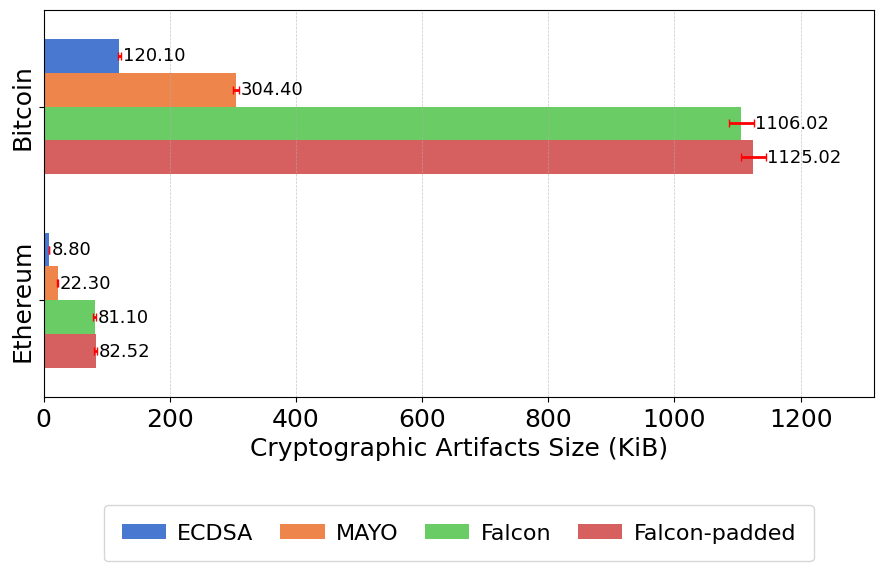

	Processing level 3 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-384'}, {'algorithm': 'mayo', 'variant': 'MAYO-3'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: ecdsa, Operation: Ethereum, Value: 12.744755068199744, Error: 0.32307945444205494
Algorithm: ecdsa, Operation: Bitcoin, Value: 174.08692511682418, Error: 2.988511394814246
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: mayo, Operation: Ethereum, Value: 71.58792368433596, Error: 1.898021670650204
Algorithm: mayo, Operation: Bitcoin, Value: 974.8512182963813, Error: 17.68567046875168
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: falcon, Operation: Ethereum, Value: 0.0, Error: 0.0
Algorithm: falcon, Operation: Bitcoin, Value: 0.0, Error: 0.0
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: falc

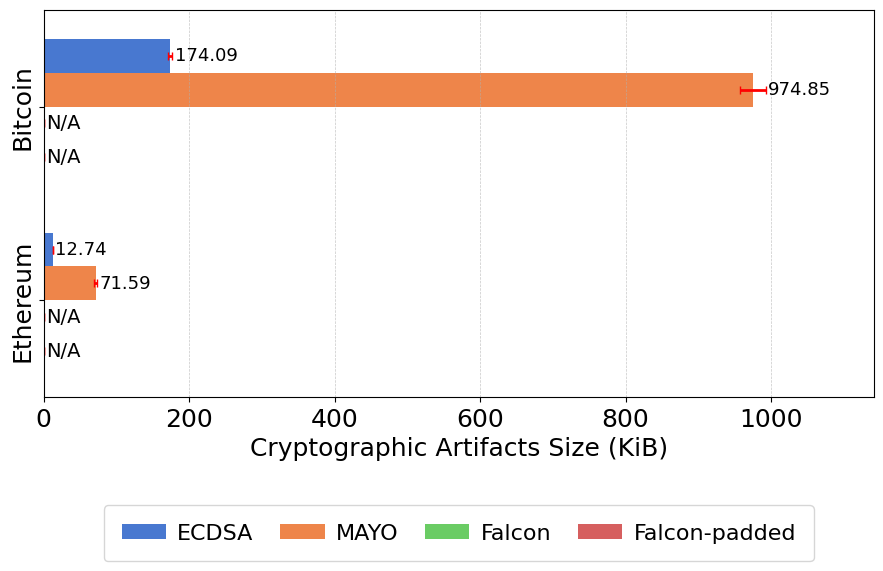

	Processing level 5 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-521'}, {'algorithm': 'falcon', 'variant': 'Falcon-1024'}, {'algorithm': 'falcon-padded', 'variant': 'Falcon-padded-1024'}, {'algorithm': 'mayo', 'variant': 'MAYO-5'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: ecdsa, Operation: Ethereum, Value: 17.16538732084152, Error: 0.4554388076648727
Algorithm: ecdsa, Operation: Bitcoin, Value: 233.96937787269297, Error: 3.9999068320044717
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: mayo, Operation: Ethereum, Value: 103.81603637302594, Error: 2.751257204787118
Algorithm: mayo, Operation: Bitcoin, Value: 1415.292277448003, Error: 25.376857937387328
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: falcon, Operation: Ethereum, Value: 157.53527538352117, Error: 4.2244368662121685
Algorithm: falcon, Opera

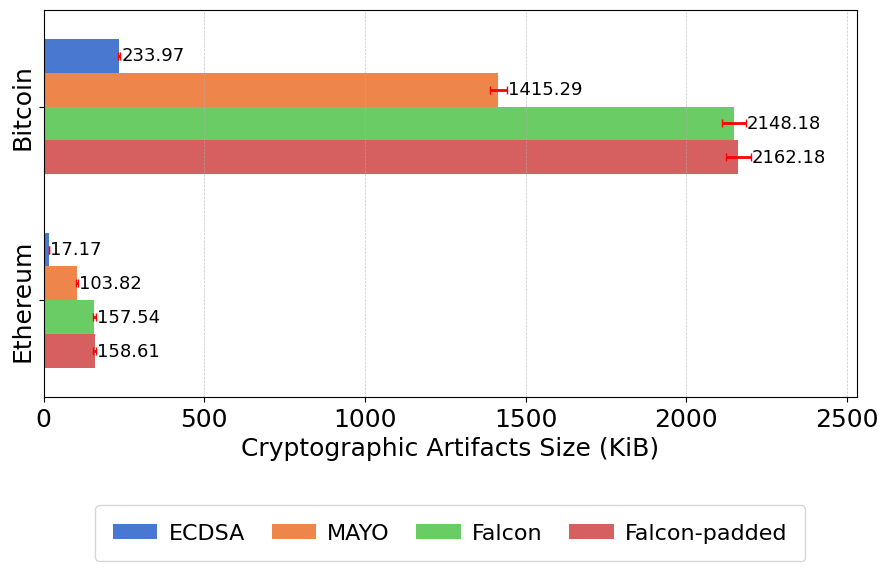

CSV Variants: {'SPHINCS+-SHA2-128f-simple', 'ML-DSA-44', 'Dilithium3', 'MAYO-3', 'cross-rsdpg-128-fast', 'Falcon-1024', 'cross-rsdp-192-small', 'cross-rsdpg-192-fast', 'MAYO-2', 'SPHINCS+-SHAKE-128s-simple', 'Dilithium2', 'cross-rsdpg-192-balanced', 'SPHINCS+-SHA2-128s-simple', 'cross-rsdp-128-fast', 'cross-rsdp-128-small', 'cross-rsdpg-192-small', 'cross-rsdpg-128-balanced', 'SPHINCS+-SHA2-256s-simple', 'SPHINCS+-SHAKE-128f-simple', 'cross-rsdp-256-small', 'cross-rsdpg-256-balanced', 'SPHINCS+-SHAKE-256f-simple', 'Dilithium5', 'Falcon-padded-512', 'cross-rsdp-192-balanced', 'ML-DSA-65', 'P-521', 'MAYO-5', 'Falcon-512', 'SPHINCS+-SHAKE-192f-simple', 'SPHINCS+-SHAKE-256s-simple', 'cross-rsdp-256-fast', 'ML-DSA-87', 'Falcon-padded-1024', 'SPHINCS+-SHA2-192f-simple', 'P-256', 'SPHINCS+-SHA2-192s-simple', 'SPHINCS+-SHA2-256f-simple', 'SPHINCS+-SHAKE-192s-simple', 'cross-rsdp-128-balanced', 'cross-rsdp-192-fast', 'cross-rsdp-256-balanced', 'cross-rsdpg-256-fast', 'cross-rsdpg-256-small', 'c

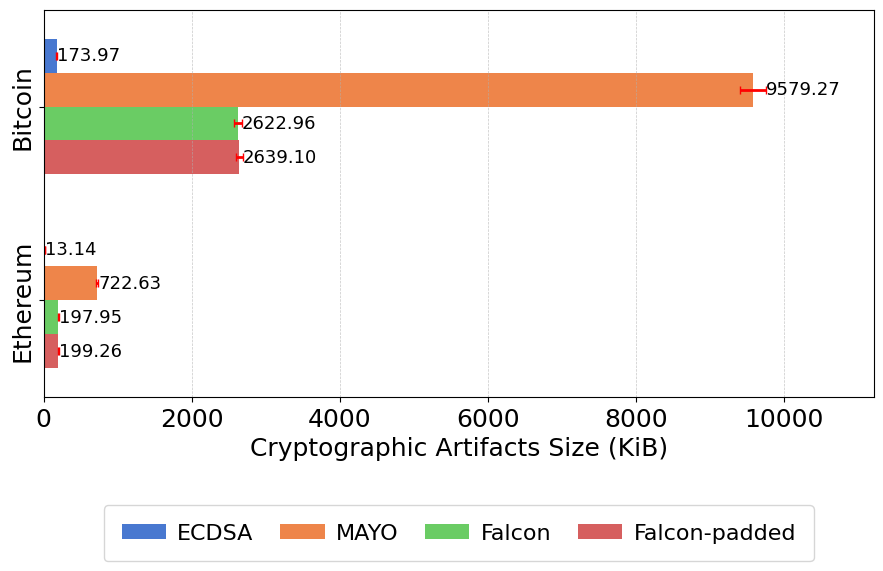

	Processing level 3 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-384'}, {'algorithm': 'mayo', 'variant': 'MAYO-3'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: ecdsa, Operation: Ethereum, Value: 19.236937740829415, Error: 0.3976770814961412
Algorithm: ecdsa, Operation: Bitcoin, Value: 255.33763229461124, Error: 4.220203471835346
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: mayo, Operation: Ethereum, Value: 412.59836446846674, Error: 8.32200826270534
Algorithm: mayo, Operation: Bitcoin, Value: 5465.540691884469, Error: 100.01446501207299
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: falcon, Operation: Ethereum, Value: 0.0, Error: 0.0
Algorithm: falcon, Operation: Bitcoin, Value: 0.0, Error: 0.0
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: falc

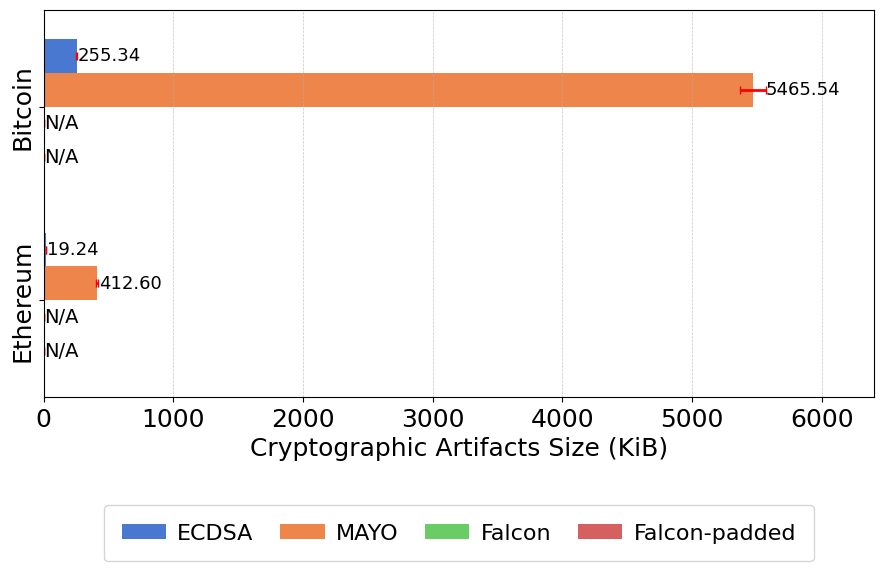

	Processing level 5 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-521'}, {'algorithm': 'falcon', 'variant': 'Falcon-1024'}, {'algorithm': 'falcon-padded', 'variant': 'Falcon-padded-1024'}, {'algorithm': 'mayo', 'variant': 'MAYO-5'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: ecdsa, Operation: Ethereum, Value: 25.94503506333452, Error: 0.5238370420836329
Algorithm: ecdsa, Operation: Bitcoin, Value: 343.909759614045, Error: 6.264247108813679
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: mayo, Operation: Ethereum, Value: 745.0337286604727, Error: 15.447077531983533
Algorithm: mayo, Operation: Bitcoin, Value: 9880.659917440986, Error: 180.87866047177894
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: falcon, Operation: Ethereum, Value: 390.6265566989199, Error: 7.941416338614153
Algorithm: falcon, Operation:

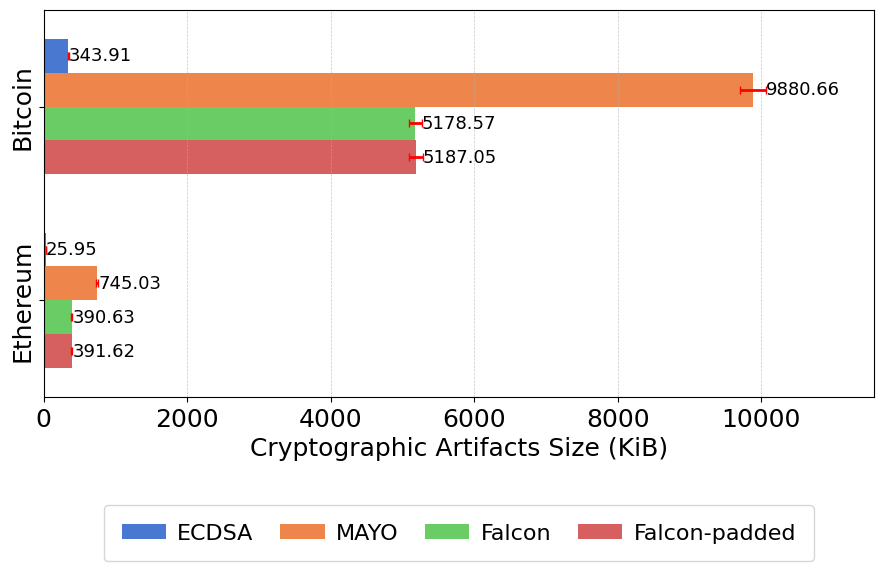

CSV Variants: {'SPHINCS+-SHA2-128f-simple', 'ML-DSA-44', 'Dilithium3', 'MAYO-3', 'cross-rsdpg-128-fast', 'Falcon-1024', 'cross-rsdp-192-small', 'cross-rsdpg-192-fast', 'MAYO-2', 'SPHINCS+-SHAKE-128s-simple', 'Dilithium2', 'cross-rsdpg-192-balanced', 'SPHINCS+-SHA2-128s-simple', 'cross-rsdp-128-fast', 'cross-rsdp-128-small', 'cross-rsdpg-192-small', 'cross-rsdpg-128-balanced', 'SPHINCS+-SHA2-256s-simple', 'SPHINCS+-SHAKE-128f-simple', 'cross-rsdp-256-small', 'cross-rsdpg-256-balanced', 'SPHINCS+-SHAKE-256f-simple', 'Dilithium5', 'Falcon-padded-512', 'cross-rsdp-192-balanced', 'ML-DSA-65', 'P-521', 'MAYO-5', 'Falcon-512', 'SPHINCS+-SHAKE-192f-simple', 'SPHINCS+-SHAKE-256s-simple', 'cross-rsdp-256-fast', 'ML-DSA-87', 'Falcon-padded-1024', 'SPHINCS+-SHA2-192f-simple', 'P-256', 'SPHINCS+-SHA2-192s-simple', 'SPHINCS+-SHA2-256f-simple', 'SPHINCS+-SHAKE-192s-simple', 'cross-rsdp-128-balanced', 'cross-rsdp-192-fast', 'cross-rsdp-256-balanced', 'cross-rsdpg-256-fast', 'cross-rsdpg-256-small', 'c

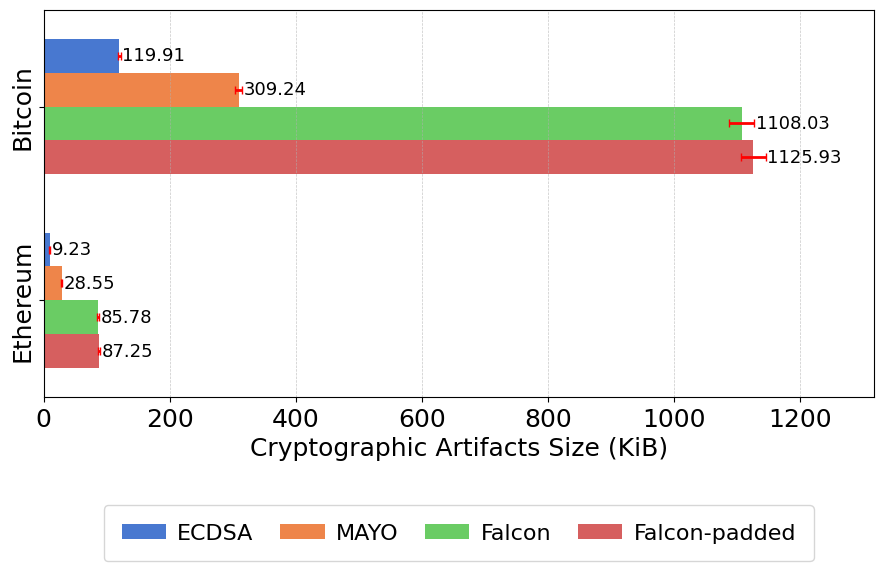

	Processing level 3 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-384'}, {'algorithm': 'mayo', 'variant': 'MAYO-3'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: ecdsa, Operation: Ethereum, Value: 13.397290226266117, Error: 0.2559365127996661
Algorithm: ecdsa, Operation: Bitcoin, Value: 173.8190344074717, Error: 3.2751996859726815
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: mayo, Operation: Ethereum, Value: 77.35779232813593, Error: 1.4007921280945759
Algorithm: mayo, Operation: Bitcoin, Value: 977.1972295661067, Error: 16.765592052116986
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: falcon, Operation: Ethereum, Value: 0.0, Error: 0.0
Algorithm: falcon, Operation: Bitcoin, Value: 0.0, Error: 0.0
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: fal

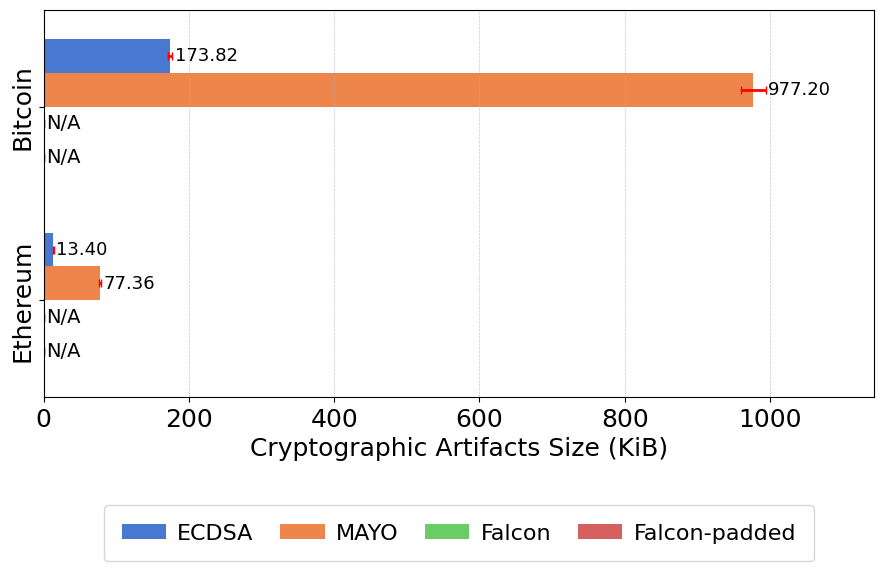

	Processing level 5 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-521'}, {'algorithm': 'falcon', 'variant': 'Falcon-1024'}, {'algorithm': 'falcon-padded', 'variant': 'Falcon-padded-1024'}, {'algorithm': 'mayo', 'variant': 'MAYO-5'}]
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: ecdsa, Operation: Ethereum, Value: 18.027499711506813, Error: 0.32649753080758825
Algorithm: ecdsa, Operation: Bitcoin, Value: 233.99755894879382, Error: 4.553263931937502
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: mayo, Operation: Ethereum, Value: 113.44664575167332, Error: 2.015059267640019
Algorithm: mayo, Operation: Bitcoin, Value: 1421.6726637270629, Error: 23.58763373486381
[('eth_mean_size', 'eth_std_size', 'Ethereum'), ('btc_mean_size', 'btc_std_size', 'Bitcoin')]
Algorithm: falcon, Operation: Ethereum, Value: 166.37263381761684, Error: 3.0849941431168957
Algorithm: falcon, Oper

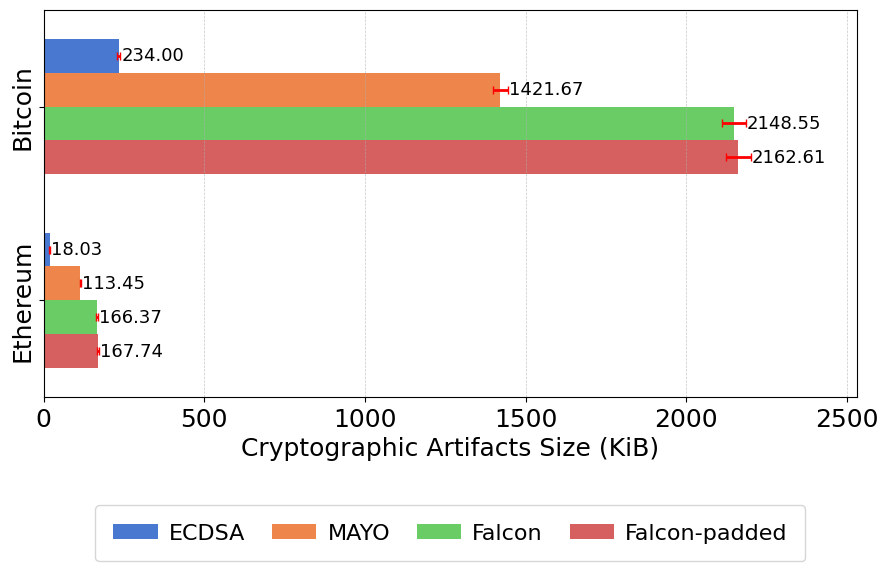

In [24]:
all_algorithms = ALGORITHMS
levels = [1, 3, 5]

sign = """ecdsa
   mayo 
   falcon
   falcon-padded
    """
sign_list = [s.strip() for s in sign.split()]

print("All algorithms loaded:", list(all_algorithms.keys()))
filtered_algorithms = filter_algorithms(all_algorithms, sign_list, levels)
print("Filtered algorithms:", filtered_algorithms)
combined_mechanisms = {}
for algorithm in filtered_algorithms.values():
    combined_mechanisms.update(algorithm)

print("Combined mechanisms:", combined_mechanisms)

for r in results.keys():
    print(f"Processing results for {r}: {results[r].keys()}")  


print("All algorithms loaded:", list(all_algorithms.keys()))

for m in ["scenario1", "scenario2", "scenario3"]:
    df_ethereum = results[m]["blocksim-model-2-mean-std"]
    df_bitcoin = results[m]["blocksim-model-1-mean-std"]
    variants_by_level = get_variants_by_level(df_ethereum, combined_mechanisms)
    print("Variants by level:", variants_by_level)
    dfs = []
    
    for level, variants in variants_by_level.items():
        print(f"\tProcessing level {level} with variants: {variants}")
        variant_to_algorithm = {v["variant"]: v["algorithm"] for v in variants}
        variant_names = [v["variant"] for v in variants]
        
        # Copy the subsets of each network.
        df_ethereum_subset = df_ethereum.loc[variant_names].copy()
        df_bitcoin_subset = df_bitcoin.loc[variant_names].copy()

        # Map the algorithms
        df_ethereum_subset["algorithm"] = df_ethereum_subset.index.map(variant_to_algorithm)
        
        # 1. Rename the Ethereum columns to avoid conflicts.
        df_combined = df_ethereum_subset.rename(columns={
            "mean_artifacts_size": "eth_mean_size",
            "std_artifacts_size": "eth_std_size"
        })
        
        # 2. Get the Bitcoin columns with unique names.
        df_combined["btc_mean_size"] = df_bitcoin_subset["mean_artifacts_size"]
        df_combined["btc_std_size"] = df_bitcoin_subset["std_artifacts_size"]
        
        # Add missing algorithms (N/A) BEFORE creating algorithm2
        for s in sign_list:
            if s not in df_combined["algorithm"].values:
                new_row = {col: 0.0 for col in df_combined.columns}
                new_row["algorithm"] = s
                new_row["variant"] = f"N/A-{s}"
                new_row_df = pd.DataFrame([new_row]).set_index("variant")
                df_combined = pd.concat([df_combined, new_row_df])
         
        # Create algorithm2
        df_combined["algorithm2"] = df_combined.apply(
            lambda x: f"{x['algorithm']}\n({x.name})" if "N/A" not in str(x.name) 
                     else x['algorithm'],
            axis=1
        )

        # Sort and categorize
        df_combined["algorithm"] = pd.Categorical(
            df_combined["algorithm"], 
            categories=sign_list, 
            ordered=True
        )
        df_combined = df_combined.sort_values("algorithm")
        
        # 3. Updates the columns that will be passed to the plotter.
        plot_columns = [
            ("eth_mean_size", "eth_std_size", "Ethereum"),
            ("btc_mean_size", "btc_std_size", "Bitcoin"),
        ]

        xscale = "linear"
        xlabel = "Cryptographic Artifacts Size (KiB)"
        yticklabels = "algorithm" 
        width = 0.7
        ylabel = None
        save_formats = ["pdf"]
        xlims={1:None, 3:None, 5:None}
        
        # 4. Call the plotter with the combined DataFrame and the correct columns.
        plot_horizontal_multiple_inverted(
            dfs=[df_combined],
            columns=plot_columns,
            graphics_directory=OUTPUT_DIR,
            values_offset=3,
            error_offset=0,
            levels=levels,
            figsize=(9, 6),
            xscale=xscale,
            xlabel=xlabel,
            xlim=(0, xlims[level]),
            yticklabels=yticklabels,
            width=width,
            titles=None,
            ylabel=ylabel,
            show_graph=True,
            show_values=True,
            show_errors=True,
            show_legend=True,
            save_formats=save_formats,
            file_name=f"sim_{m}_level-{level}",
            pallet_start=0,
            legend_location="lower right" 
        )